In [17]:
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Kết nối Google Drive để truy cập dữ liệu
drive.mount('/content/drive')

Mounted at /content/drive


<ipython-input-18-86df8e97ba7a>:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hanoi_cleaned = df_hanoi_cleaned.fillna(method='ffill')


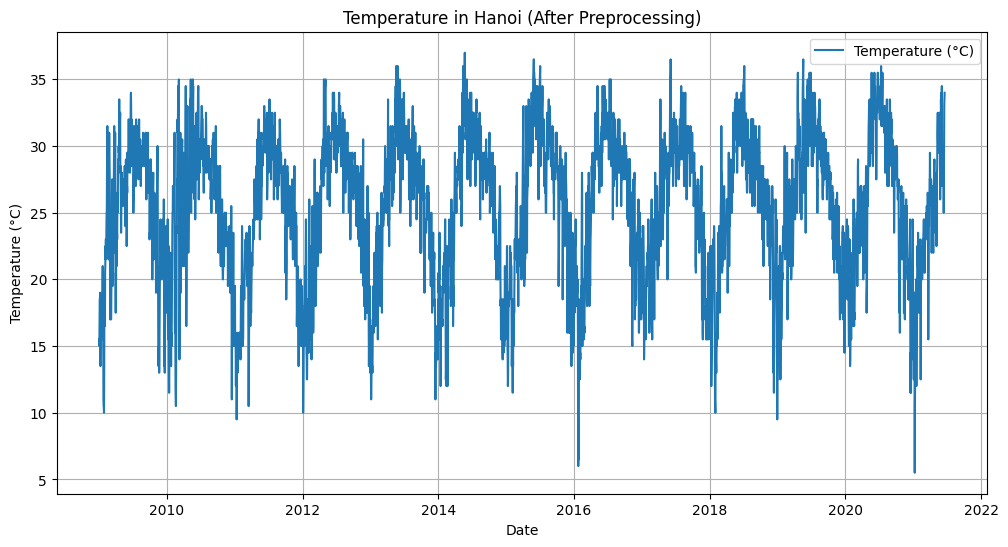

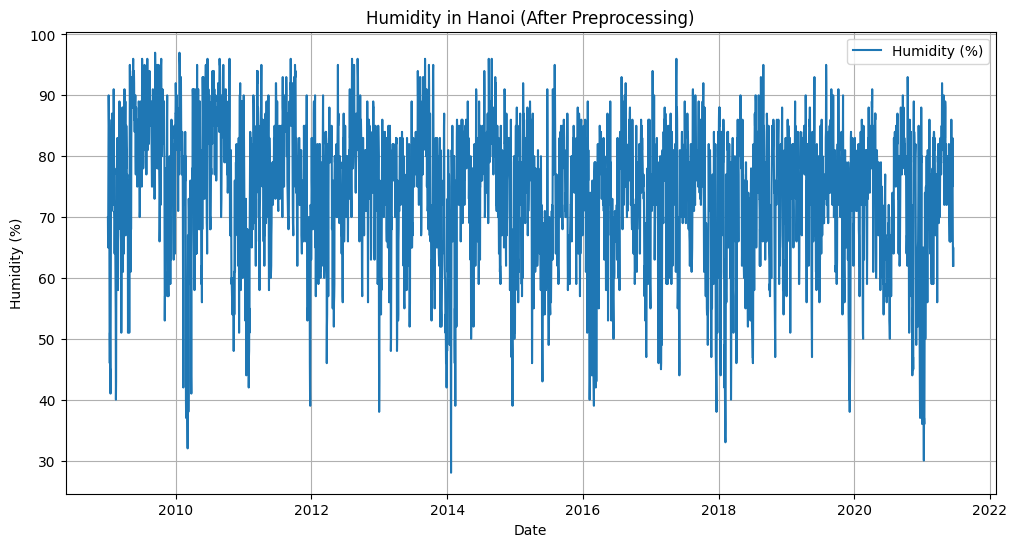

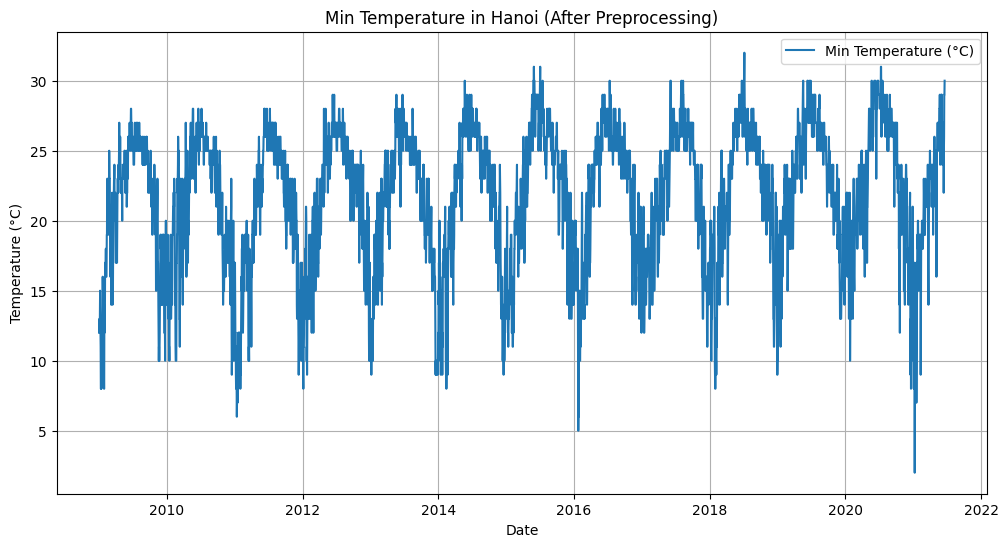

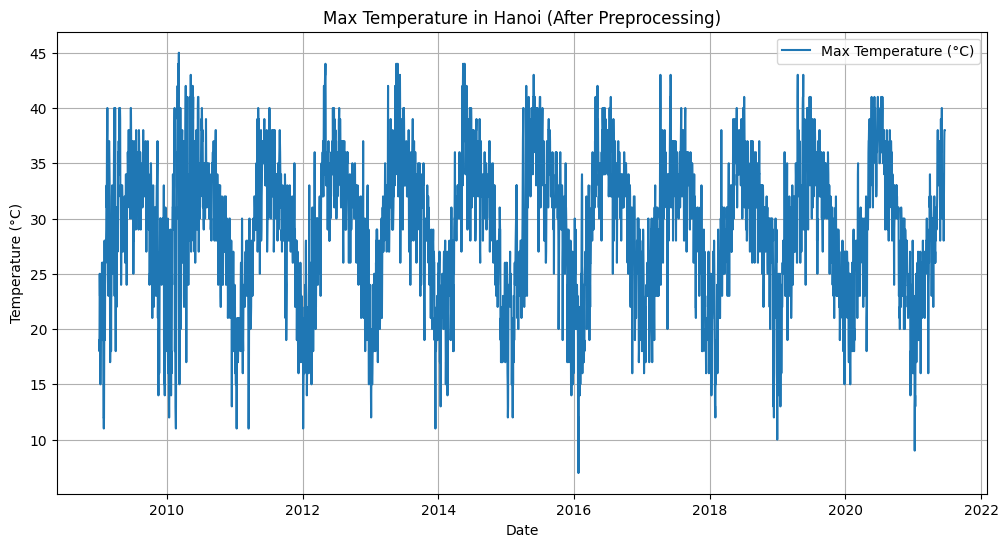

In [18]:
# Mục tiêu: Tiền xử lý dữ liệu thời tiết Hà Nội để chuẩn bị cho dự báo đa biến
df = pd.read_csv('/content/drive/My Drive/weather (1).csv', parse_dates=['date'])

# Lọc dữ liệu cho Hà Nội
df_hanoi = df[df['province'].str.lower().str.strip().isin(['ha noi', 'hanoi'])]

# Sắp xếp theo ngày và xử lý giá trị thiếu
df_hanoi_cleaned = df_hanoi.sort_values('date')
df_hanoi_cleaned = df_hanoi_cleaned.fillna(method='ffill')

# Tính Temperature (trung bình của max và min) nếu không có cột riêng
if 'temperature' not in df_hanoi_cleaned.columns:
    df_hanoi_cleaned['temperature'] = (df_hanoi_cleaned['max'] + df_hanoi_cleaned['min']) / 2

# Chọn các cột để dự báo: temperature, humidi, min, max
data = df_hanoi_cleaned[['temperature', 'humidi', 'min', 'max']].values

# Chuẩn hóa dữ liệu
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Trực quan hóa dữ liệu
plt.figure(figsize=(12, 6))
plt.plot(df_hanoi_cleaned['date'], df_hanoi_cleaned['temperature'], label='Temperature (°C)')
plt.title('Temperature in Hanoi (After Preprocessing)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_hanoi_cleaned['date'], df_hanoi_cleaned['humidi'], label='Humidity (%)')
plt.title('Humidity in Hanoi (After Preprocessing)')
plt.xlabel('Date')
plt.ylabel('Humidity (%)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_hanoi_cleaned['date'], df_hanoi_cleaned['min'], label='Min Temperature (°C)')
plt.title('Min Temperature in Hanoi (After Preprocessing)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_hanoi_cleaned['date'], df_hanoi_cleaned['max'], label='Max Temperature (°C)')
plt.title('Max Temperature in Hanoi (After Preprocessing)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Mục tiêu: Chuẩn bị dữ liệu chuỗi thời gian cho dự báo đa biến
seq_length = 60
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, seq_length)

# Chia dữ liệu thành tập train, valid, test (80/10/10)
train_size = int(len(X) * 0.8)
valid_size = int(len(X) * 0.1)
test_size = len(X) - train_size - valid_size

X_train = X[:train_size]
y_train = y[:train_size]
X_valid = X[train_size:train_size + valid_size]
y_valid = y[train_size:train_size + valid_size]
X_test = X[train_size + valid_size:]
y_test = y[train_size + valid_size:]

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - loss: 0.0476 - val_loss: 0.0094
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - loss: 0.0094 - val_loss: 0.0074
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - loss: 0.0074 - val_loss: 0.0055
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 0.0054 - val_loss: 0.0043
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - loss: 0.0035 - val_loss: 0.0039
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 9/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 10/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 11/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 12/50
226/226 ━━━━━━━━━━

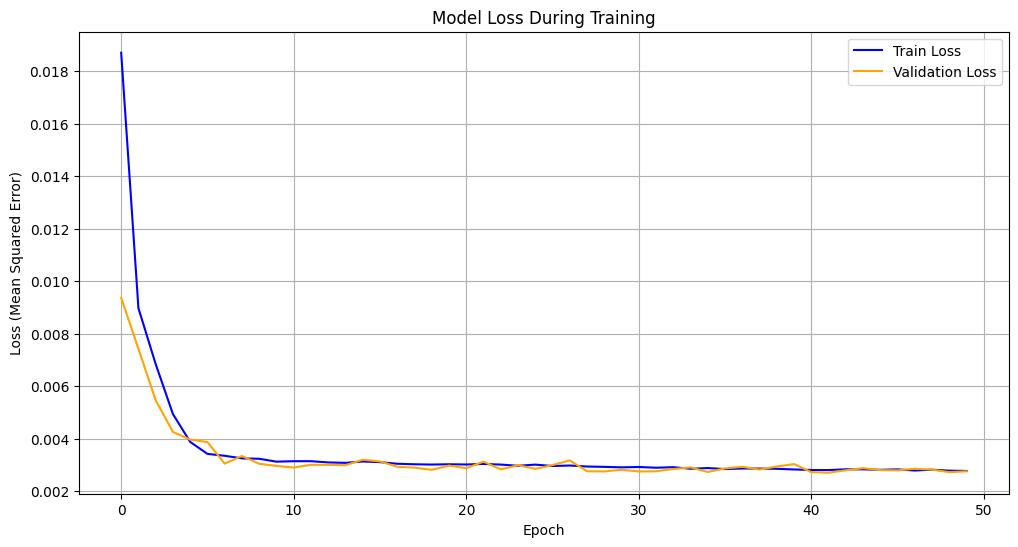

In [23]:
# Mục tiêu: Xây dựng và huấn luyện mô hình LSTM để dự báo đa biến
def build_lstm_model(seq_length, n_features):
    """
    Xây dựng mô hình LSTM.
    Args:
        seq_length: Độ dài chuỗi đầu vào.
        n_features: Số lượng biến (features).
    Returns:
        Mô hình LSTM đã được biên dịch.
    """
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(seq_length, n_features)))
    model.add(LSTM(units=50))
    model.add(Dense(units=n_features))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Số lượng biến (temperature, humidi, min, max)
n_features = 4

# Xây dựng mô hình
model = build_lstm_model(seq_length, n_features)

# Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_valid, y_valid), verbose=1)

# Vẽ biểu đồ mất mát
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

Đang dự đoán trên tập huấn luyện...
Dự đoán trên tập huấn luyện hoàn tất.
Đang dự đoán trên tập kiểm tra...
Dự đoán trên tập kiểm tra hoàn tất.
Đang dự đoán trên tập thử nghiệm...
Dự đoán trên tập thử nghiệm hoàn tất.

Kết quả đánh giá mô hình LSTM trên tập huấn luyện:

# Tính các chỉ số thống kê cho Temperature
mae_temperature = mean_absolute_error(y_tập_huấn_luyện_temperature, tập huấn luyện_pred_temperature)
rmse_temperature = np.sqrt(mean_squared_error(y_tập_huấn_luyện_temperature, tập huấn luyện_pred_temperature))
r2_temperature = r2_score(y_tập_huấn_luyện_temperature, tập huấn luyện_pred_temperature)
Temperature:
MAE: 0.86 °C
RMSE: 1.39 °C
R²: 0.93

# Tính các chỉ số thống kê cho Humidity
mae_humidity = mean_absolute_error(y_tập_huấn_luyện_humidity, tập huấn luyện_pred_humidity)
rmse_humidity = np.sqrt(mean_squared_error(y_tập_huấn_luyện_humidity, tập huấn luyện_pred_humidity))
r2_humidity = r2_score(y_tập_huấn_luyện_humidity, tập huấn luyện_pred_humidity)
Humidity:
MAE: 3.25 %
R

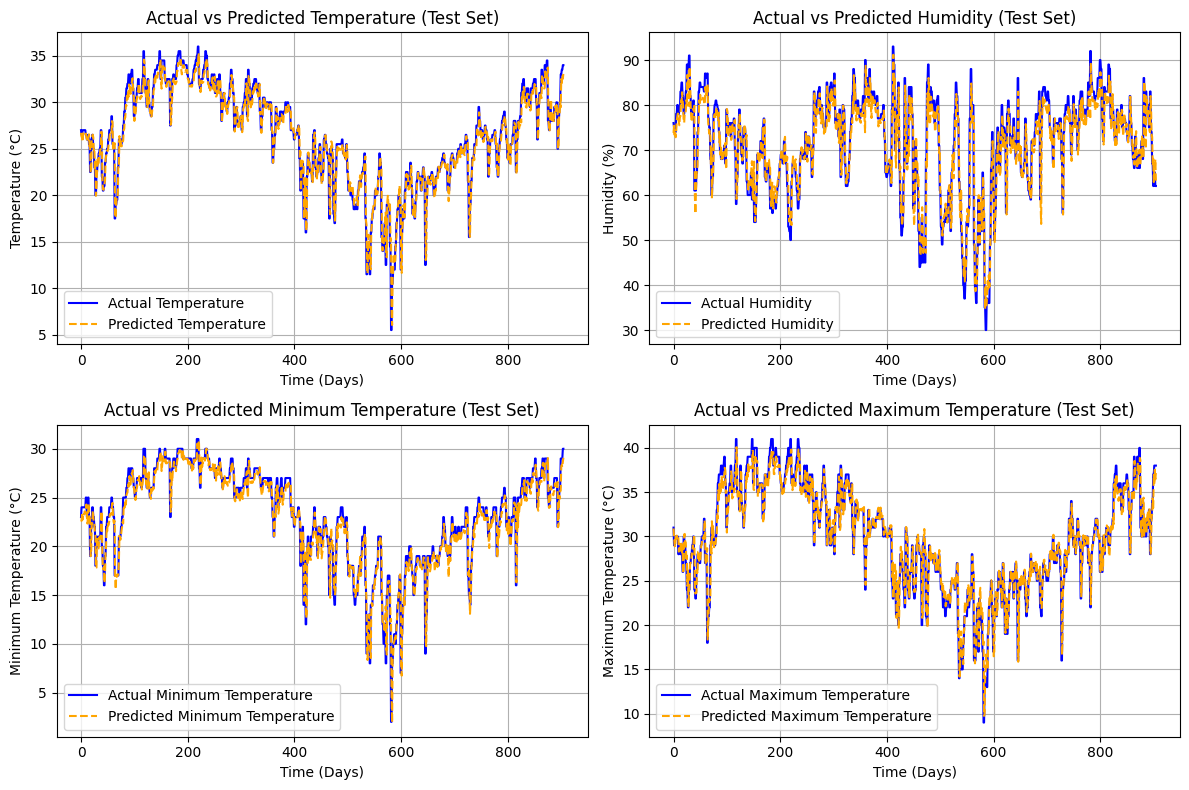

In [25]:
# Mục tiêu: Dự đoán trên các tập dữ liệu và đánh giá hiệu suất
def calculate_metrics(y_true, y_pred):
    """
    Tính các chỉ số đánh giá: MAE, RMSE, R².
    Args:
        y_true: Giá trị thực tế.
        y_pred: Giá trị dự đoán.
    Returns:
        Tuple chứa MAE, RMSE, R².
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Kiểm tra và dự đoán trên các tập dữ liệu
if 'model' not in globals():
    raise NameError("Mô hình 'model' chưa được định nghĩa. Vui lòng chạy Cell 4 trước!")

print("Đang dự đoán trên tập huấn luyện...")
train_predictions = model.predict(X_train, verbose=0)
print("Dự đoán trên tập huấn luyện hoàn tất.")

print("Đang dự đoán trên tập kiểm tra...")
valid_predictions = model.predict(X_valid, verbose=0)
print("Dự đoán trên tập kiểm tra hoàn tất.")

print("Đang dự đoán trên tập thử nghiệm...")
test_predictions = model.predict(X_test, verbose=0)
print("Dự đoán trên tập thử nghiệm hoàn tất.")

# Chuẩn hóa ngược giá trị dự đoán và thực tế
train_predictions_unscaled = scaler.inverse_transform(train_predictions)
y_train_unscaled = scaler.inverse_transform(y_train)
valid_predictions_unscaled = scaler.inverse_transform(valid_predictions)
y_valid_unscaled = scaler.inverse_transform(y_valid)
test_predictions_unscaled = scaler.inverse_transform(test_predictions)
y_test_unscaled = scaler.inverse_transform(y_test)

# Tách các biến từ kết quả dự đoán
variables = ['Temperature', 'Humidity', 'Minimum Temperature', 'Maximum Temperature']
units = ['°C', '%', '°C', '°C']

# Tập train
train_metrics = {}
for i, var in enumerate(variables):
    y_true = y_train_unscaled[:, i]
    y_pred = train_predictions_unscaled[:, i]
    mae, rmse, r2 = calculate_metrics(y_true, y_pred)
    train_metrics[var] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

# Tập valid
valid_metrics = {}
for i, var in enumerate(variables):
    y_true = y_valid_unscaled[:, i]
    y_pred = valid_predictions_unscaled[:, i]
    mae, rmse, r2 = calculate_metrics(y_true, y_pred)
    valid_metrics[var] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

# Tập test
test_metrics = {}
for i, var in enumerate(variables):
    y_true = y_test_unscaled[:, i]
    y_pred = test_predictions_unscaled[:, i]
    mae, rmse, r2 = calculate_metrics(y_true, y_pred)
    test_metrics[var] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

# Hiển thị kết quả theo định dạng yêu cầu
def display_metrics(metrics, dataset_name):
    print(f"\nKết quả đánh giá mô hình LSTM trên {dataset_name}:")
    for i, var in enumerate(variables):
        print(f"\n# Tính các chỉ số thống kê cho {var}")
        print(f"mae_{var.lower().replace(' ', '_')} = mean_absolute_error(y_{dataset_name.lower().replace(' ', '_')}_{var.lower().replace(' ', '_')}, {dataset_name.lower()}_pred_{var.lower().replace(' ', '_')})")
        print(f"rmse_{var.lower().replace(' ', '_')} = np.sqrt(mean_squared_error(y_{dataset_name.lower().replace(' ', '_')}_{var.lower().replace(' ', '_')}, {dataset_name.lower()}_pred_{var.lower().replace(' ', '_')}))")
        print(f"r2_{var.lower().replace(' ', '_')} = r2_score(y_{dataset_name.lower().replace(' ', '_')}_{var.lower().replace(' ', '_')}, {dataset_name.lower()}_pred_{var.lower().replace(' ', '_')})")
        print(f"{var}:")
        print(f"MAE: {metrics[var]['MAE']:.2f} {units[i]}")
        print(f"RMSE: {metrics[var]['RMSE']:.2f} {units[i]}")
        print(f"R²: {metrics[var]['R²']:.2f}")

# Hiển thị kết quả cho tập train, valid, test
display_metrics(train_metrics, "tập huấn luyện")
display_metrics(valid_metrics, "tập kiểm tra")
display_metrics(test_metrics, "tập thử nghiệm")

# Trực quan hóa kết quả trên tập test
plt.figure(figsize=(12, 8))
for i, var in enumerate(variables):
    y_true = y_test_unscaled[:, i]
    y_pred = test_predictions_unscaled[:, i]
    plt.subplot(2, 2, i + 1)
    plt.plot(y_true, label=f'Actual {var}', color='blue')
    plt.plot(y_pred, label=f'Predicted {var}', color='orange', linestyle='--')
    plt.title(f'Actual vs Predicted {var} (Test Set)')
    plt.xlabel('Time (Days)')
    plt.ylabel(var + f' ({units[i]})')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()